In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from medmnist import PathMNIST

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
CUDA disponível: False


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cpu


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

In [4]:
train_set = PathMNIST(split="train", size=28, transform=transform, download=True)
val_set = PathMNIST(split="val", size=28, transform=transform, download=True)

print("Treino:", len(train_set))
print("Validação:", len(val_set))

Treino: 89996
Validação: 10004


In [5]:
train_subset = torch.utils.data.Subset(train_set, range(5000))
val_subset = torch.utils.data.Subset(val_set, range(1000))

batch_size = 64

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))

Batches de treino: 79
Batches de validação: 16


In [6]:
imagens, labels = next(iter(train_loader))

print("Formato das imagens:", imagens.shape)
print("Formato dos labels:", labels.shape)
print("Primeiros labels:", labels[:5].squeeze())

Formato das imagens: torch.Size([64, 3, 28, 28])
Formato dos labels: torch.Size([64, 1])
Primeiros labels: tensor([1, 1, 2, 2, 1])


In [7]:
class MLPPathMNIST(nn.Module):
    def __init__(self, input_size=2352, hidden_size=128, output_size=9):
        super().__init__()

        self.modelo = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.modelo(x)

In [8]:
modelo = MLPPathMNIST().to(device)

criterio = nn.CrossEntropyLoss()

otimizador = optim.SGD(
    modelo.parameters(),
    lr=0.01,
    momentum=0.9
)

print(modelo)

MLPPathMNIST(
  (modelo): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2352, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=9, bias=True)
  )
)


In [9]:
def treinar_uma_epoca(modelo, dataloader, criterio, otimizador, device):
    modelo.train()

    perda_total = 0
    acertos = 0
    total = 0

    for imagens, labels in dataloader:
        imagens = imagens.to(device)
        labels = labels.squeeze().long().to(device)

        otimizador.zero_grad()

        saidas = modelo(imagens)
        perda = criterio(saidas, labels)

        perda.backward()
        otimizador.step()

        perda_total += perda.item() * imagens.size(0)

        previsoes = torch.argmax(saidas, dim=1)
        acertos += (previsoes == labels).sum().item()
        total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia


def avaliar(modelo, dataloader, criterio, device):
    modelo.eval()

    perda_total = 0
    acertos = 0
    total = 0

    with torch.no_grad():
        for imagens, labels in dataloader:
            imagens = imagens.to(device)
            labels = labels.squeeze().long().to(device)

            saidas = modelo(imagens)
            perda = criterio(saidas, labels)

            perda_total += perda.item() * imagens.size(0)

            previsoes = torch.argmax(saidas, dim=1)
            acertos += (previsoes == labels).sum().item()
            total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia

In [10]:
historico_torch = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 20

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        modelo,
        train_loader,
        criterio,
        otimizador,
        device
    )

    loss_val, acc_val = avaliar(
        modelo,
        val_loader,
        criterio,
        device
    )

    historico_torch["loss_train"].append(loss_train)
    historico_torch["acc_train"].append(acc_train)
    historico_torch["loss_val"].append(loss_val)
    historico_torch["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

Época 01 | Loss treino: 2.1414 | Acc treino: 0.1796 | Loss val: 2.0297 | Acc val: 0.2120
Época 02 | Loss treino: 1.9580 | Acc treino: 0.2342 | Loss val: 1.9081 | Acc val: 0.2960
Época 03 | Loss treino: 1.8939 | Acc treino: 0.2556 | Loss val: 1.9180 | Acc val: 0.2560
Época 04 | Loss treino: 1.8318 | Acc treino: 0.2946 | Loss val: 1.8428 | Acc val: 0.2810
Época 05 | Loss treino: 1.7637 | Acc treino: 0.3270 | Loss val: 1.7633 | Acc val: 0.3580
Época 06 | Loss treino: 1.7216 | Acc treino: 0.3422 | Loss val: 1.7703 | Acc val: 0.3800
Época 07 | Loss treino: 1.7194 | Acc treino: 0.3526 | Loss val: 1.9199 | Acc val: 0.2470
Época 08 | Loss treino: 1.7289 | Acc treino: 0.3378 | Loss val: 1.7407 | Acc val: 0.3480
Época 09 | Loss treino: 1.6771 | Acc treino: 0.3768 | Loss val: 1.7060 | Acc val: 0.3450
Época 10 | Loss treino: 1.7390 | Acc treino: 0.3428 | Loss val: 1.6943 | Acc val: 0.3100
Época 11 | Loss treino: 1.6776 | Acc treino: 0.3690 | Loss val: 1.8394 | Acc val: 0.3390
Época 12 | Loss trein

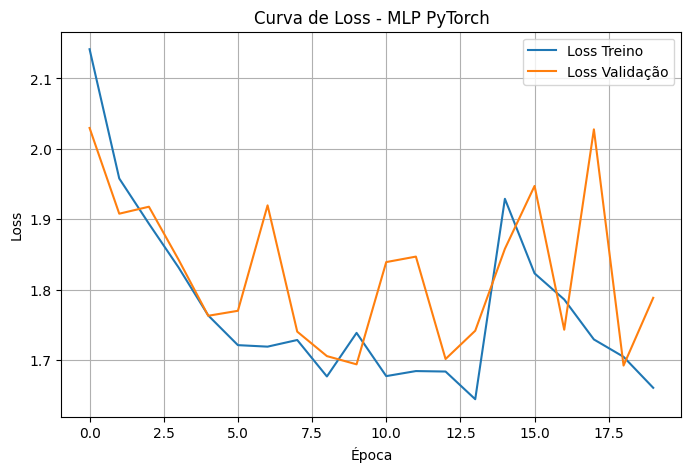

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(historico_torch["loss_train"], label="Loss Treino")
plt.plot(historico_torch["loss_val"], label="Loss Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss - MLP PyTorch")
plt.legend()
plt.grid(True)
plt.show()

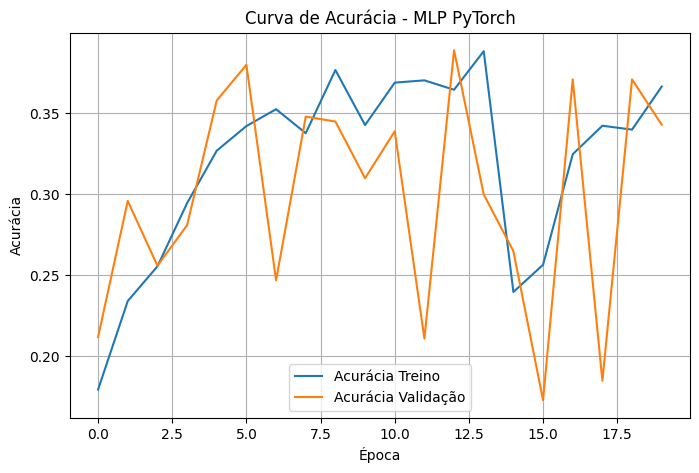

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(historico_torch["acc_train"], label="Acurácia Treino")
plt.plot(historico_torch["acc_val"], label="Acurácia Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva de Acurácia - MLP PyTorch")
plt.legend()
plt.grid(True)
plt.show()

## Comparação com a MLP em NumPy

A MLP implementada em PyTorch utilizou a mesma ideia geral da versão em NumPy: entrada achatada com 2352 atributos, uma camada oculta com 128 neurônios e saída com 9 classes.

A versão em NumPy obteve aproximadamente 25,2% de acurácia na validação após 20 épocas. Já a versão em PyTorch obteve aproximadamente 34,3% de acurácia na validação após 20 épocas.

A diferença pode ser explicada por detalhes de implementação, uso de mini-batches, inicialização dos pesos, operações internas otimizadas do PyTorch e pequenas diferenças no processo de treinamento. Apesar disso, ambas demonstraram redução da loss e aumento da acurácia, indicando comportamento de convergência.